# INTRODUCTION

In today's data-driven world, accurately predicting the probability of loan defaults is crucial for financial institutions. With the rising complexity of financial markets and the increasing volume of data available, developing robust predictive models is more important than ever. This project focuses on building a machine learning model to estimate the probability of default (PD) on loans, utilizing historical loan data.

## The objectives of this project are as follows:

* Data Cleaning:   We will preprocess the dataset to ensure its quality and suitability for analysis.
* Exploratory Data Analysis (EDA):   Through visualization and statistical analysis, we aim to uncover insights regarding borrower     characteristics and their relationship with loan defaults.
* Feature Selection:   Identifying the most relevant features will help enhance model performance and interpretability.
* Model Building:   We will train multiple machine learning models, optimizing them for the best predictive accuracy.
* Model Evaluation:   A rigorous evaluation process will be employed to assess model performance using various metrics.
*  Deployment: Finally, we will develop API endpoints for model inference, enabling real-world applications.

This notebook will utilize various Python libraries and tools to achieve these objectives. Let’s start by importing the necessary libraries to set up our environment for analysis and model development


In [1]:
# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

# we want our plots to appear inside the notebook
%matplotlib inline 

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve




In [2]:
df = pd.read_csv("data_science_competition_2024.csv")
print(f"COLUMNS : {df.columns}")
print()
print(f"SHAPE: {df.shape}")
df.head(3)


COLUMNS : Index(['Unnamed: 0', 'loan_id', 'gender', 'disbursemet_date', 'currency',
       'country', 'sex', 'is_employed', 'job', 'location', 'loan_amount',
       'number_of_defaults', 'outstanding_balance', 'interest_rate', 'age',
       'number_of_defaults.1', 'remaining term', 'salary', 'marital_status',
       'age.1', 'Loan Status'],
      dtype='object')

SHAPE: (100000, 21)


,Unnamed: 0,loan_id,gender,disbursemet_date,currency,country,sex,is_employed,job,location,...,number_of_defaults,outstanding_balance,interest_rate,age,number_of_defaults.1,remaining term,salary,marital_status,age.1,Loan Status
0,0,8d05de78-ff32-46b1-aeb5-b3190f9c158a,female,2022 10 29,USD,Zimbabwe,female,True,Teacher,Beitbridge,...,0,48653.011473,0.22,37,0,47,3230.038869,married,37,Did not default
1,1,368bf756-fcf2-4822-9612-f445d90b485b,other,2020 06 06,USD,Zimbabwe,other,True,Teacher,Harare,...,2,28752.062237,0.20,43,2,62,3194.139103,single,43,Did not default
2,2,6e3be39e-49b5-45b5-aab6-c6556de53c6f,other,2023 09 29,USD,Zimbabwe,other,True,Nurse,Gweru,...,1,44797.554126,0.22,43,1,57,3330.826656,married,43,Did not default


In [3]:
df.isna().sum()

Unnamed: 0                 0
loan_id                    0
gender                     0
disbursemet_date           0
currency                   0
country                  100
sex                        0
is_employed                0
job                     4136
location                 595
loan_amount                0
number_of_defaults         0
outstanding_balance        0
interest_rate              0
age                        0
number_of_defaults.1       0
remaining term             0
salary                     0
marital_status             0
age.1                      0
Loan Status                0
dtype: int64

<Axes: xlabel='Loan Status'>

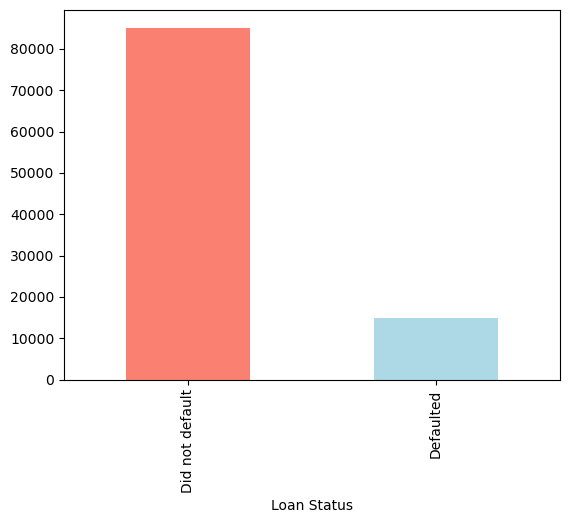

In [4]:
df["Loan Status"].value_counts().plot( kind="bar" , color =["salmon","lightblue"])

## Structure Overview
* The dataset has 100000 rows and 21 columns.
* It has both categorical and numerical features.
* It is extremly imbalanced.
* It has a missing values in the job , location and country colums

## PRIMARY DATA CLEANING

### Feature data type correction

In [5]:
df.dtypes


Unnamed: 0                int64
loan_id                  object
gender                   object
disbursemet_date         object
currency                 object
country                  object
sex                      object
is_employed                bool
job                      object
location                 object
loan_amount             float64
number_of_defaults        int64
outstanding_balance     float64
interest_rate           float64
age                       int64
number_of_defaults.1      int64
remaining term           object
salary                  float64
marital_status           object
age.1                     int64
Loan Status              object
dtype: object

* As you can see from above , The remaining term is described as an object instead of integer

In [6]:
#identify categorical columns

categorical_col = ["job", "location", "marital_status", "gender"]

for col in categorical_col :
    print(f"Value counts for '{col}': ")
    print(df[col].value_counts())
    print()

Value counts for 'job': 
job
Engineer              16524
Nurse                 15284
Data Analyst          13204
Doctor                12186
Software Developer    11932
Teacher                8950
Accountant             7802
SoftwareDeveloper      3564
Data Scientist         3521
Lawyer                 2862
Data Scintist            35
Name: count, dtype: int64

Value counts for 'location': 
location
Harare               8338
Bulawayo             8078
Mutare               8062
Gweru                7803
Masvingo             7476
                     ... 
 Redcliff               1
Victoria Falls          1
Victoria Falls          1
   Gokwe                1
Gokwe                   1
Name: count, Length: 157, dtype: int64

Value counts for 'marital_status': 
marital_status
married     44710
divorced    26465
single      25698
             3127
Name: count, dtype: int64

Value counts for 'gender': 
gender
male      35028
female    32685
other     32287
Name: count, dtype: int64



## From above we can notice

1. lncorrect spellings furthur differantiating same categories in location job currency and country
2. There i sadditionaal unlabeled white space in marital status column
3. Remaining term contains a mixture of strings and intergers


## Convet remaining term dtype to int

In [7]:
df["remaining term"].dtype

dtype('O')

In [8]:
#coverting remaining term feature to consistently become numerical

# Convert to string firts to handle non numerics characters
df["remaining term"] = df["remaining term"].astype(str)

#Remove underscores and extra spaces
df["remaining term"] = df["remaining term"].str.replace("_", "").str.strip()

#Now converting back to numericat if all the values are intended to be numeric
df["remaining term"] = pd.to_numeric(df["remaining term"], errors="coerce")

df["remaining term"].dtype

dtype('int64')

## Feature category spelling correction

In [43]:
print(df["location"].value_counts().sort_values().to_string())

location
Gokwe                    1
   Zvishavane            1
 Victoria Falls          1
   Gokwe                 1
Victoria Falls           1
 Redcliff                1
Victoria Falls           1
 Zvishavane              2
Gokwe                    2
 Victoria Falls          2
 Gokwe                   2
   Kariba                2
   Kariba                3
   Redcliff              3
   Victoria Falls        3
 Kariba                  3
 Kariba                  3
Kariba                   4
Kariba                   4
   Shurugwi              4
   Zvishavane            4
Kadoma                   5
 Shurugwi                5
   Nyanga                5
 Nyanga                  5
   Kadoma                6
Zvishavane               6
   Shurugwi              6
 Gokwe                   6
 Zvishavane              6
Shurugwi                 6
Zvishavane               6
   Karoi                 6
 Shurugwi                7
Karoi                    7
   Gokwe                 7
 Karoi             

## Correct and normalize location spellings

In [44]:
#location feature textual normalization
df['location'] = df['location'].str.strip()

# convert lowercase
df['location'] = df['location'].str.lower()

# Create a dictionary to map incorrect variations to correct values
mapping = {
    'harare': 'Harare',
    'bulawayo': 'Bulawayo',
    'mutare': 'Mutare',
    'gweru': 'Gweru',
    'masvingo': 'Masvingo',
    'marondera': 'Marondera',
    'rusape': 'Rusape',
    'chivhu': 'Chivhu',
    'plumtree': 'Plumtree',
    'beitbridge': 'Beitbridge',
    'chipinge': 'Chipinge',
    'chimanimani': 'Chimanimani',
    'kwekwe': 'Kwekwe',
    'chiredzi': 'Chiredzi',
    'kadoma': 'Kadoma',
    'nyanga': 'Nyanga',
    'karoi': 'Karoi',
    'shurugwi': 'Shurugwi',
    'zvishavane': 'Zvishavane',
    'gokwe': 'Gokwe',
    'kariba': 'Kariba',
    'victoria falls': 'Victoria Falls',
    'redcliff': 'Redcliff',
    'hwange': 'Hwange'
}

# Replace incorrect values using the mapping dictionary
df['location'] = df['location'].replace(mapping)



print(df['location'].value_counts())
# the locations are now normalized


location
Harare            8553
Bulawayo          8263
Mutare            8262
Gweru             7983
Masvingo          7665
Marondera         7513
Rusape            6506
Chivhu            6411
Plumtree          5552
Beitbridge        5311
Chipinge          4447
Chimanimani       4388
Kwekwe            3491
Chiredzi          3199
Kadoma            3118
Nyanga            2142
Karoi             1899
Shurugwi          1359
Zvishavane        1301
Gokwe              920
Kariba             671
Victoria Falls     219
Redcliff           191
Hwange              41
Name: count, dtype: int64
